In [36]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
from utils_part2 import load_data_to_batch

result_path = f'/homes/ar2342/one_more_dir/contextual_frogs/results_part2/default_with_seeds_{4}/'


In [47]:


a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))

seeds = 128//2 # 128*2#*2 # 18#72#18 #128
subjs = a_exp.shape[1] // seeds


all_ys, _all_a_exp, _all_qs, _lengths = load_data_to_batch(subjs, 1, 'ERSR')


In [48]:
np.shape(all_ys)

(16, 340)

In [3]:
from models_part2 import BatchedElboGenerativeModelTopMulti
import yaml
from types import SimpleNamespace
args_path = os.path.join(result_path, 'args.yaml')
with open(args_path, 'r') as f:
    args_dict = yaml.unsafe_load(f) #safe_load(f)
args = SimpleNamespace(**args_dict)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [4]:
def compute_k_params(model_state_dict, 
                     exclude_by_startwith=['_'], 
                     exclude_by_name=['sigma_x'], 
                     count_for_one={'sigma_b', 'direct_injection_scale','output_scale','u_feedback_scale', 
                                    'x_slow_alpha', 'x_fast_gain', 'x_fast_alpha'}):
    k_params = 0
    for key in model_state_dict:
        if any([key.startswith(excl) for excl in exclude_by_startwith]):
            continue
        if key in exclude_by_name:
            continue
        param_tensor = model_state_dict[key]
        this_param_size = param_tensor.shape[-1] if key not in count_for_one else 1
        print(f'param: {key}, size: {this_param_size}')
        k_params += this_param_size
    return k_params

In [5]:
rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])

n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
#ensure n_samples is same in every row
assert np.all(n_samples == n_samples[:, [0]])
n_samples = n_samples[:, 0]

best_seed_idx = np.nanargmin(rmse, axis=1)
# best_rmse = np.nanmin(rmse, axis=1)
best_rmse = rmse[np.arange(subjs), best_seed_idx]


/tmp/ipykernel_2169657/3765835614.py:1: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])


In [6]:
#read saved model parameters
model_state_dict = torch.load(os.path.join(result_path, 'model_state_dict.pt'), map_location='cpu')
# if result_path_aux is not None:
#     model_state_dict_aux = torch.load(os.path.join(result_path_aux, 'model_state_dict.pt'), map_location='cpu')
# plt.hist(model_state_dict['output_scale'].cpu().numpy(), bins=30)
k_params = compute_k_params(model_state_dict)
print(f'detected k_params: {k_params}')

param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5


In [7]:
args.bs = subjs  #set batch size to number of subjects

In [8]:
best_seed_idx_within_batch = best_seed_idx +(np.arange(subjs) * seeds)

#create a new model state dict with only the best seeds (seeds are the leading dimension of each parameter tensor)
best_model_state_dict = {}
for key, value in model_state_dict.items():
        print(key, value.shape)
        best_model_state_dict[key] = value[best_seed_idx_within_batch] if not key.startswith('_') else value


log_learning_rate torch.Size([1024, 1])
log_learning_rate_decay torch.Size([1024, 1])
sigma_b torch.Size([1024])
output_scale torch.Size([1024])
sp_weight_decay torch.Size([1024, 1])
sigma_x torch.Size([1024])
_z_biases torch.Size([1024])
_w_in torch.Size([1024])
_w_inq torch.Size([1024])


In [ ]:

model = BatchedElboGenerativeModelTopMulti(device=device, args=args, 
                                           **(dict(fudge=args.fudge) if hasattr(args, 'fudge') else {}  )).to(device)
model.get_biases_and_w_in(args.n, device=device)
model.load_state_dict(best_model_state_dict)


(tensor([[-0.1413,  0.0645,  0.6272,  ...,  0.0415,  0.2875, -0.0223],
         [-0.2093,  0.0955,  0.9292,  ...,  0.0615,  0.4259, -0.0331],
         [-0.9255,  0.4221,  4.1078,  ...,  0.2720,  1.8829, -0.1461],
         ...,
         [-0.1982,  0.0904,  0.8798,  ...,  0.0582,  0.4033, -0.0313],
         [-0.1618,  0.0738,  0.7181,  ...,  0.0475,  0.3291, -0.0255],
         [ 0.9505, -0.4335, -4.2188,  ..., -0.2793, -1.9337,  0.1501]],
        device='cuda:0', grad_fn=<MulBackward0>),
 tensor([ 0.6135, -0.1708, -1.0005,  ...,  1.1626,  0.3177,  0.0468],
        device='cuda:0'))

In [53]:
def local_eval_paradigms(model, playlist_file, args, broadcast_ys=True):
    with open(playlist_file, 'rb') as f:
        playlist = pickle.load(f)

    model.eval()
    with torch.no_grad():
        outputs = {}
        for paradigm_name,paradigm in playlist.items():
            print(f'evaluating paradigm {paradigm_name} with {len(paradigm)} steps')
            ys = torch.tensor(paradigm, device=next(model.parameters()).device)
            #duplicate ys across batch size

            if broadcast_ys:
                ys = ys.unsqueeze(0).repeat(args.bs, 1)  # [bs, t]
            
            # noises = torch.randn((args.bs, ys.shape[1]), device=next(model.parameters()).device) * model.sigma_x  # [bs, t]
            noises = torch.zeros((args.bs, ys.shape[1]), device=next(model.parameters()).device)  # [bs, t]
            noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
            ys = [ys[:, t_idx] for t_idx in range(ys.shape[1])]
            print(f'noises shape: {noises[0].shape}, ys shape: {ys[0].shape}')
            model_setting = args.model
            outputs_ = model.f(args.n,
                                noises,
                                ys,  
                                model_setting,
                                qs=None,
                                )
            outputs[paradigm_name] = np.array([z.cpu().numpy().reshape(-1) for z in outputs_]) 
    return outputs

def local_eval_ys(model, ys, args, broadcast_ys=True):
    model.eval()
    with torch.no_grad():
        print(f'evaluating ys with {ys.shape[0]} steps')
        ys = torch.tensor(ys, device=next(model.parameters()).device)
        #duplicate ys across batch size

        if broadcast_ys:
            ys = ys.unsqueeze(0).repeat(args.bs, 1)  # [bs, t]
        
        # noises = torch.randn((args.bs, ys.shape[1]), device=next(model.parameters()).device) * model.sigma_x  # [bs, t]
        noises = torch.zeros((args.bs, ys.shape[1]), device=next(model.parameters()).device)  # [bs, t]
        noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
        ys = [ys[:, t_idx] for t_idx in range(ys.shape[1])]
        print(f'noises shape: {noises[0].shape}, ys shape: {ys[0].shape}')
        model_setting = args.model
        outputs_ = model.f(args.n,
                            noises,
                            ys,  
                            model_setting,
                            qs=None,
                            )
        outputs = np.array([z.cpu().numpy().reshape(-1) for z in outputs_]) 
    return outputs

In [54]:
local_preds = local_eval_ys(model, np.array(all_ys), args,broadcast_ys=False)

evaluating ys with 16 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


Text(0, 0.5, 'adaptation')

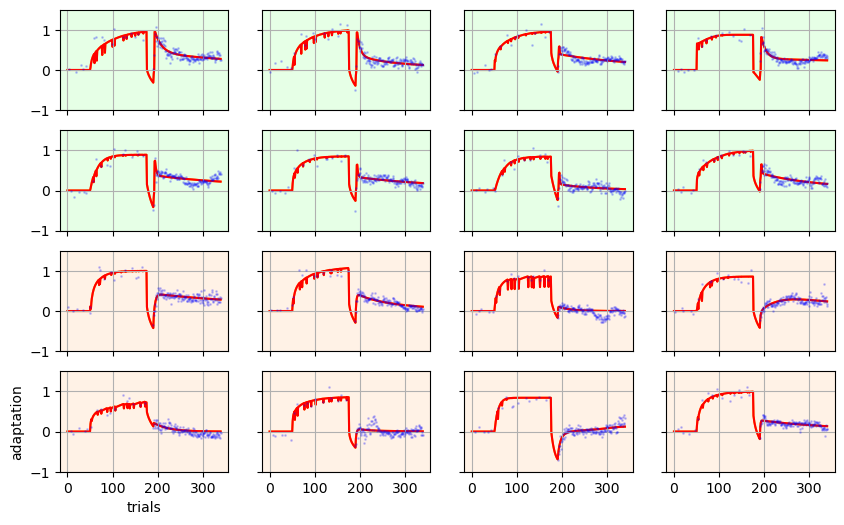

In [55]:
lerner_switch = False


plt.figure(figsize=(10, 6))
plt.subplot(4, 4, 1)
cnt=0
for ii, (this_exp, this_pred) in enumerate(zip(a_exp.T, a_pred.T)):
    this_sub = ii//seeds
    plt.subplot(4, 4, 1 + this_sub)
    polarity = np.sign(np.nanmean(this_exp[:175]))
    if ii % seeds == 0:
        plt.plot(polarity*this_exp,'.', label='Experimental', color='blue', markersize=2, alpha=0.2)
    if ii % seeds == best_seed_idx[this_sub]:
        plt.plot(polarity*this_pred, label='Predicted', color='orange',zorder=0)
        plt.plot(polarity*local_preds[:, this_sub], label='Predicted', color='red',zorder=0)
        
        plt.grid() #; print(cnt); cnt+=1
        plt.ylim([-1,1.5])

    if this_sub % 4 > 0:
        plt.gca().set_yticklabels([])
    if this_sub < 12:
        plt.gca().set_xticklabels([])

    if not lerner_switch:
        if this_sub <8:
            # plt.axvspan(0, 340, color='green', alpha=0.01)
            plt.gca().set_facecolor((0.9,1,0.9))
        else:
            # plt.axvspan(0,340, color='orange', alpha=0.1)
            plt.gca().set_facecolor((1,0.95,0.9))
    else:
        if this_sub <15:
            # plt.axvspan(0, 340, color='green', alpha=0.01)
            plt.gca().set_facecolor((0.9,0.9,1))
        else:
            # plt.axvspan(0,340, color='orange', alpha=0.1)
            plt.gca().set_facecolor((0.8,0.7,1))
plt.subplot(4, 4, 13)
plt.xlabel('trials')
plt.ylabel('adaptation')
# plt.title('Experimental vs Predicted Data')
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/ersrFitsM19.pdf', format='pdf', bbox_inches='tight')# 
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/lernerFitsM19.pdf', format='pdf', bbox_inches='tight')

In [13]:
these_bics = [bic_gaussian_from_rmse(this_rmse, n=this_n, k=k_params) for this_rmse, this_n in zip(best_rmse, n_samples)]

In [14]:
coin_bics_path = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/coin_bics1000.txt'
coin_bics = np.loadtxt(coin_bics_path)

<StemContainer object of 3 artists>

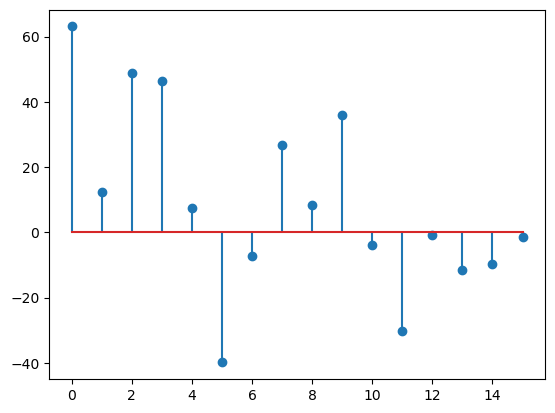

In [15]:
plt.stem(these_bics-coin_bics)

In [16]:
dual_rate_bics = np.loadtxt('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/dual_rate_bics_v1.txt')


Text(11, -50, 'SR')

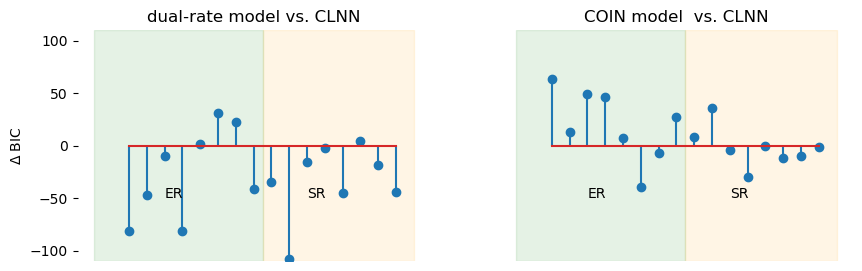

In [17]:
plt.figure(figsize=(10, 3))
plt.subplot (1, 2, 1)
plt.stem(np.arange(1, 17), these_bics - dual_rate_bics)
plt.axvspan(-1, 8.5, color='green', alpha=0.1)
plt.axvspan(8.5,17, color='orange', alpha=0.1)
plt.box('off')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.ylim([-110, 110])
plt.xticks([])
# plt.ylabel('\Delta BIC  dual-rate model\n linear decay vs. power law decay \n positive = linear better')
plt.ylabel('$\Delta$ BIC')
plt.title('dual-rate model vs. CLNN')# \n positive = dual rate better')
plt.text(3,-50,'ER')
plt.text(8+3,-50,'SR')

plt.subplot (1, 2, 2)
plt.stem(np.arange(1, 17), these_bics - coin_bics)
plt.axvspan(-1, 8.5, color='green', alpha=0.1)
plt.axvspan(8.5,17, color='orange', alpha=0.1)
plt.box('off')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.ylim([-110, 110])

plt.xticks([])
plt.yticks([])
# plt.ylabel('\Delta BIC  dual-rate model\n linear decay vs. power law decay \n positive = linear better')
# plt.ylabel('$\Delta$ BIC')
plt.title('COIN model  vs. CLNN') # \n positive = COIN model better')
plt.text(3,-50,'ER')
plt.text(8+3,-50,'SR')
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/ersrBIC.pdf', format='pdf', bbox_inches='tight')

In [18]:
''' Lerner's variant

plt.figure(figsize=(5, 3))
plt.subplot (1, 1, 1)
plt.stem(np.arange(1, 17), these_bics - (lerner_dual_rate_bics['best_bics']))
plt.axvspan(-1, 15.5, color=(0.9,0.9,1))#, alpha=0.1)
plt.axvspan(15.5,17, color=(0.8,0.7,1))#, alpha=0.1)
plt.box('off')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.ylim([-60, 20])
plt.xticks([])
# plt.ylabel('\Delta BIC  dual-rate model\n linear decay vs. power law decay \n positive = linear better')
plt.ylabel('$\Delta$ BIC')
plt.title('dual-rate model vs. CLNN')# \n positive = dual rate better')
plt.text(3,-50,'Individual  Fits \n (Anterograde Interference)')
plt.text(16.2,-40,'Mean Fit', rotation=90, va='center')
'''
# plt.subplot (1, 2, 2)
# plt.stem(np.arange(1, 17), these_bics - coin_bics)
# plt.axvspan(-1, 8.5, color='green', alpha=0.1)
# plt.axvspan(8.5,17, color='orange', alpha=0.1)
# plt.box('off')
# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)
# plt.gca().spines['left'].set_visible(False)
# plt.gca().spines['bottom'].set_visible(False)
# plt.ylim([-110, 110])

# plt.xticks([])
# plt.yticks([])
# # plt.ylabel('\Delta BIC  dual-rate model\n linear decay vs. power law decay \n positive = linear better')
# # plt.ylabel('$\Delta$ BIC')
# plt.title('COIN model  vs. CLNN') # \n positive = COIN model better')
# plt.text(3,-50,'ER')
# plt.text(8+3,-50,'SR')
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/lernerBICg1.pdf', format='pdf', bbox_inches='tight')

" Lerner's variant\n\nplt.figure(figsize=(5, 3))\nplt.subplot (1, 1, 1)\nplt.stem(np.arange(1, 17), these_bics - (lerner_dual_rate_bics['best_bics']))\nplt.axvspan(-1, 15.5, color=(0.9,0.9,1))#, alpha=0.1)\nplt.axvspan(15.5,17, color=(0.8,0.7,1))#, alpha=0.1)\nplt.box('off')\nplt.gca().spines['top'].set_visible(False)\nplt.gca().spines['right'].set_visible(False)\nplt.gca().spines['left'].set_visible(False)\nplt.gca().spines['bottom'].set_visible(False)\nplt.ylim([-60, 20])\nplt.xticks([])\n# plt.ylabel('\\Delta BIC  dual-rate model\n linear decay vs. power law decay \n positive = linear better')\nplt.ylabel('$\\Delta$ BIC')\nplt.title('dual-rate model vs. CLNN')# \n positive = dual rate better')\nplt.text(3,-50,'Individual  Fits \n (Anterograde Interference)')\nplt.text(16.2,-40,'Mean Fit', rotation=90, va='center')\n"

In [19]:
ref_temp_rmse = np.array([0.14388285, 0.13275064, 0.18496574, 0.09147181, 0.16228775,
       0.1605799 , 0.18684085, 0.13883465, 0.11473347, 0.169773  ,
       0.20617779, 0.20484355, 0.10975336, 0.09605098, 0.18166255,
       0.1527941 , 0.16023854, 0.13980691, 0.16267194, 0.13959636,
       0.1403273 , 0.14730662, 0.12016405, 0.15779249])

In [20]:
# np.sum(best_rmse - ref_temp_rmse)

In [21]:
import pickle

In [22]:
args_path

'/homes/ar2342/one_more_dir/contextual_frogs/results_part2/default_with_seeds_4/args.yaml'

In [23]:
paradigm_file='/homes/ar2342/one_more_dir/contextual_frogs/signoffrepertoire4.3.pkl'
# force_model_params(model, forced_params)

ooo = local_eval_paradigms(model, paradigm_file, args)

evaluating paradigm savings with 440 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB0 with 280 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB1 with 293 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB2 with 321 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB3 with 392 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB4 with 510 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB5 with 690 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm spontaneous with 340 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm evoked with 340 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm visw1p2 with 1150 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


KeyboardInterrupt: 

In [ ]:
# pooling_fun = np.nanmedian
# pooling_fun = np.nanmean
pooling_fun = np.mean

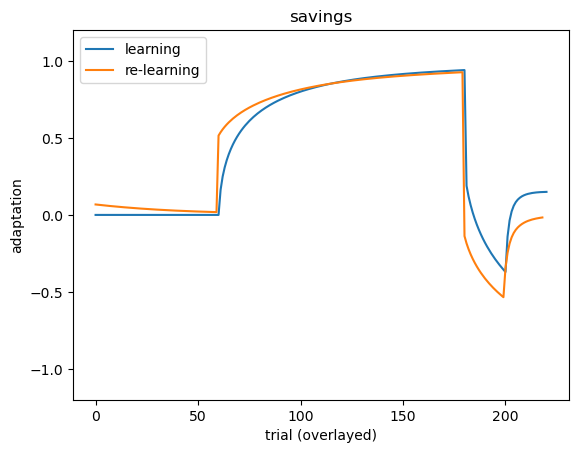

In [ ]:
plt.plot(pooling_fun(ooo['savings'][:221], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['savings'][221:], axis=1), label='re-learning')
# for subj in range(subjs):
    # plt.plot(ooo['savings'][221:, subj], color='gray', alpha=0.3)
plt.title('savings')
plt.xlabel('trial (overlayed)')
plt.ylabel('adaptation')
plt.ylim([-1.2, 1.2])
plt.legend()

In [ ]:
from dsp_utils import smooth_signal

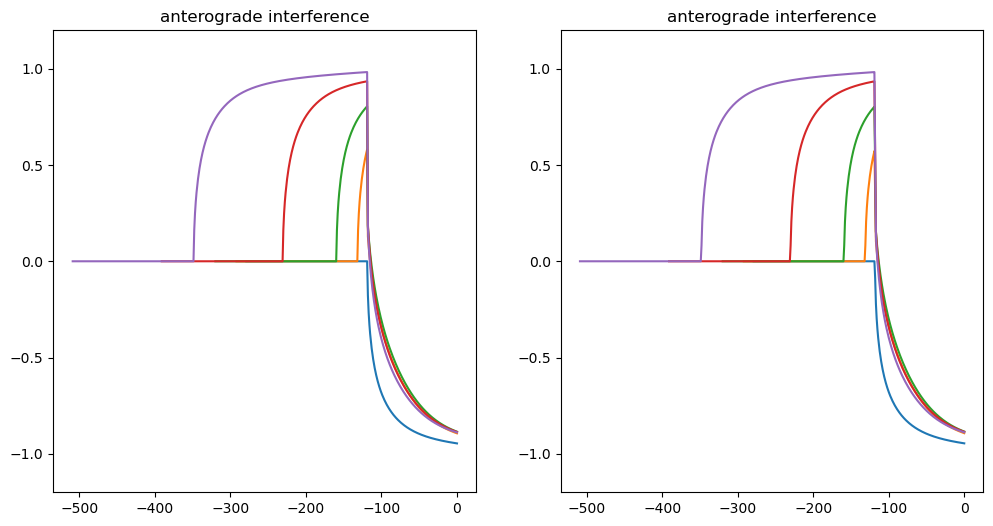

In [ ]:
ant_list = [f'AB{i}' for i in range(0,5)]

plt.figure(figsize=(12,6))
for ii, smooth_fun in enumerate([lambda x: x,lambda x: smooth_signal(x, 2)]):
    plt.subplot(1,2,ii+1)
    plt.title('anterograde interference')
    for ant in ant_list:
        x_data = np.arange(len(ooo[ant].mean(axis=1)))
        # plt.plot(x_data,smooth_fun(pooling_fun(ooo[ant], axis=1)))
        plt.plot(x_data-np.max(x_data),smooth_fun(pooling_fun(ooo[ant], axis=1)))
        # for subj in range(subjs):
        #     plt.plot(x_data-np.max(x_data),ooo[ant][:, subj], color='gray', alpha=0.3)
    plt.ylim([-1.2, 1.2])

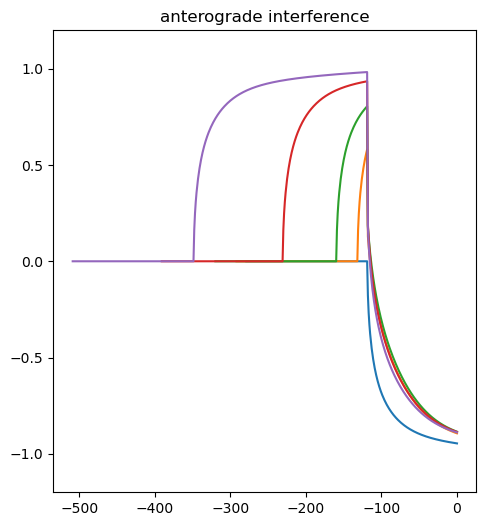

In [ ]:
ant_list = [f'AB{i}' for i in range(0,5)]

plt.figure(figsize=(12,6))
for ii, smooth_fun in enumerate([lambda x: x]): #,lambda x: smooth_signal(x, 2)]):
    plt.subplot(1,2,ii+1)
    plt.title('anterograde interference')
    for ant in ant_list:
        x_data = np.arange(len(ooo[ant].mean(axis=1)))
        plt.plot(x_data-np.max(x_data),smooth_fun(pooling_fun(ooo[ant], axis=1)))
    plt.ylim([-1.2, 1.2])

Text(0.5, 1.0, 'environmental consistency')

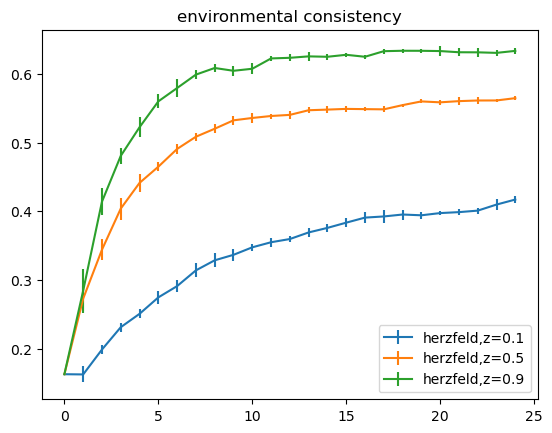

In [ ]:
deltas_by_super_scenario = {}
for i, this_data in enumerate([ooo]):

    for iz, z in enumerate(ooo.keys()):
        if 'herzfeld' not in z:
            continue
        else:
            scenario = z
            super_scenario = z.split('$')[0]
        deltas = []
        mm = lambda x: np.mean(x,axis=0)
        this_result = pooling_fun(this_data[scenario],axis=1)
        pointer = 0
        for bb in range(25):
            block_length = len(this_result)//25
            deltas.append(this_result[pointer+2]-this_result[pointer])
            pointer += block_length

        if super_scenario not in deltas_by_super_scenario:
            deltas_by_super_scenario[super_scenario] = []
        deltas_by_super_scenario[super_scenario].append(deltas)

plt.figure()
for k in deltas_by_super_scenario:

    data = np.array(deltas_by_super_scenario[k])
    mean = np.mean(data,axis=0)
    std = np.std(data,axis=0)
    plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)

plt.legend()
plt.title('environmental consistency')
# plt.ylim(-1,1.2)

processing subject 0, scenario herzfeld,z=0.1$0, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$0, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.9$0, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.1$1, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$1, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.9$1, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.1$2, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$2, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.9$2, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.1$3, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$3, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.9$3, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.1$4, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$4, re

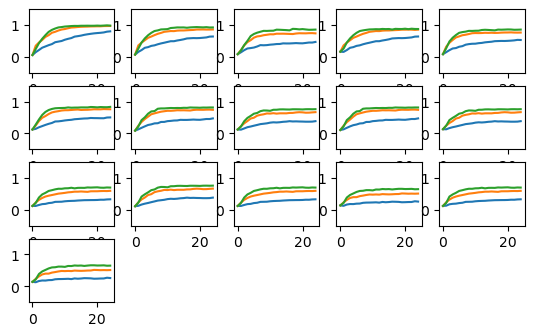

In [ ]:
deltas_by_super_scenario = {}
for pp in range(subjs):
    plt.subplot(5,5,pp+1)

    for i, this_data in enumerate([ooo]):
        # print(i)
        for iz, z in enumerate(ooo.keys()):
            if 'herzfeld' not in z:
                continue
            else:
                scenario = z
                super_scenario = z.split('$')[0]
            deltas = []
            mm = lambda x: np.mean(x,axis=0)
            # scenario = f'herzfeld,z={z}'
            # this_result = this_data[scenario].mean(axis=1)
            print(f'processing subject {pp}, scenario {scenario}, result shape {this_data[scenario].shape}')
            # this_result = pooling_fun(this_data[scenario],axis=1)
            this_result = this_data[scenario][:,pp]
            pointer = 0
            for bb in range(25):
                block_length = len(this_result)//25
                # pointer += block_length
                # deltas.append(this_result[pointer-1]-this_result[pointer-3])
                deltas.append(this_result[pointer+2]-this_result[pointer])
                pointer += block_length

            if super_scenario not in deltas_by_super_scenario:
                deltas_by_super_scenario[super_scenario] = []
            deltas_by_super_scenario[super_scenario].append(deltas)
            # plt.plot(deltas,'x',label = f'z={z}')
            # plt.title('environmental consistency')
        # plt.legend(loc='upper right')
    # plt.figure()
        for k in deltas_by_super_scenario:
            # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
            #present with error bars
            data = np.array(deltas_by_super_scenario[k])
            mean = np.nanmedian(data,axis=0)
            # std = np.std(data,axis=0)
            # plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
            plt.plot(np.arange(len(mean)),mean,label=k)

        # plt.legend()
        # plt.title('environmental consistency')
        plt.ylim(-0.5,1.5)

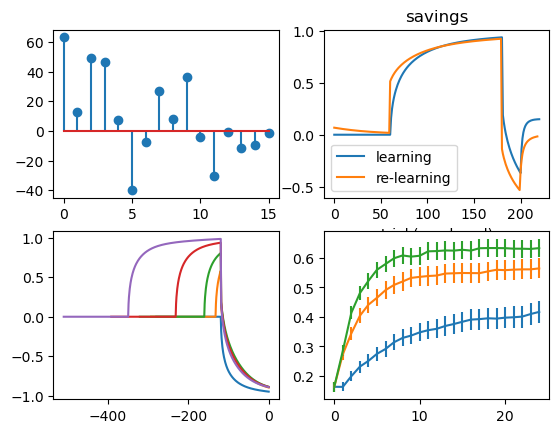

In [ ]:
plt.subplot(2,2,1)
plt.stem(these_bics-coin_bics)
plt.subplot(2,2,2)
plt.plot(pooling_fun(ooo['savings'][:221], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['savings'][221:], axis=1), label='re-learning')
# for subj in range(subjs):
    # plt.plot(ooo['savings'][221:, subj], color='gray', alpha=0.3)
plt.title('savings')
plt.xlabel('trial (overlayed)')
# plt.ylabel('adaptation')
plt.legend()
plt.subplot(2,2,3)
# plt.title('anterograde interference')
for ant in ant_list:
    x_data = np.arange(len(ooo[ant].mean(axis=1)))
    plt.plot(x_data-np.max(x_data),pooling_fun(ooo[ant], axis=1))
    # for subj in range(subjs):
    #     plt.plot(x_data-np.max(x_data),ooo[ant][:, subj], color='gray', alpha=0.3)
plt.subplot(2,2,4)
for k in deltas_by_super_scenario:
    # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
    #present with error bars
    data = np.array(deltas_by_super_scenario[k])
    mean = pooling_fun(data,axis=0)
    std = np.std(data,axis=0)
    plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
    # plt.plot(np.arange(len(mean)),mean,label=k)


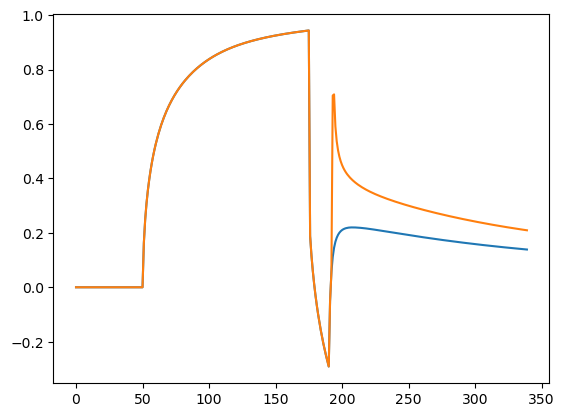

In [ ]:
plt.plot(pooling_fun(ooo['spontaneous'], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['evoked'], axis=1) , label='learning')

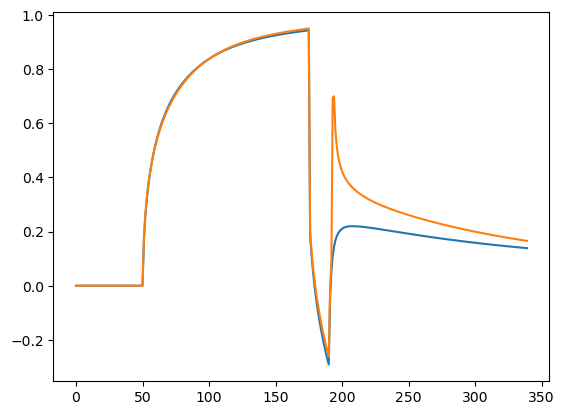

In [ ]:
plt.plot(pooling_fun(ooo['spontaneous'], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['evoked'][:,list(range(14))+[15]], axis=1) , label='learning')

In [ ]:
list(range(16))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

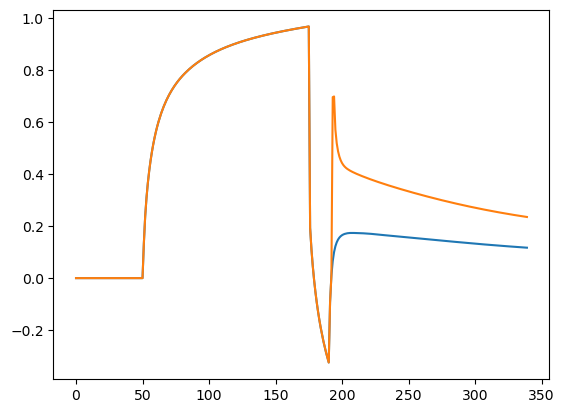

In [ ]:
plt.plot(pooling_fun(ooo['spontaneous'][:,8:], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['evoked'][:,8:], axis=1) , label='learning')

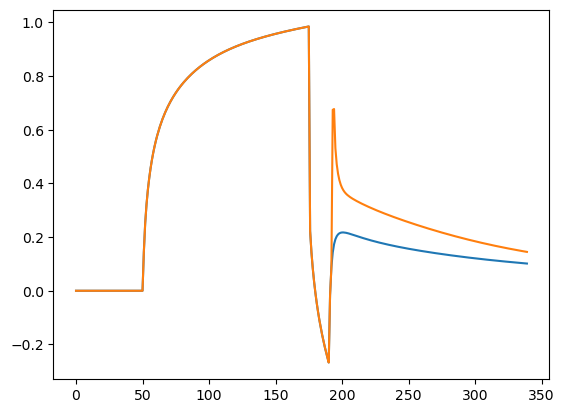

In [ ]:
plt.plot(pooling_fun(ooo['spontaneous'][:,[8,9,10,11,12,13,15]], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['evoked'][:,[8,9,10,11,12,13,15]], axis=1) , label='learning')

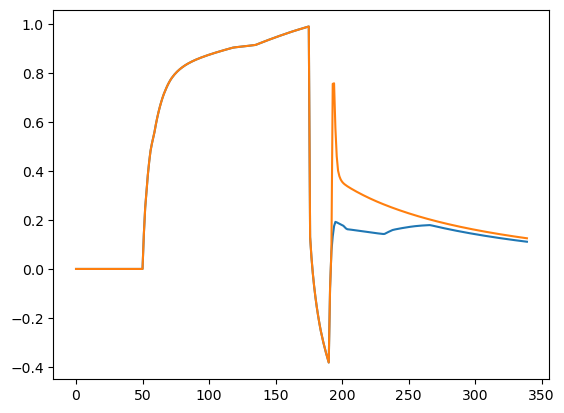

In [ ]:
plt.plot(np.median(ooo['spontaneous'][:,8:], axis=1) , label='learning')
plt.plot(np.median(ooo['evoked'][:,8:], axis=1) , label='learning')

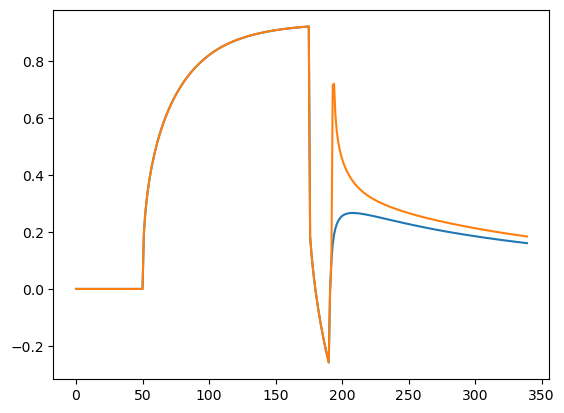

In [ ]:
plt.plot(pooling_fun(ooo['spontaneous'][:,:8], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['evoked'][:,:8], axis=1) , label='learning')

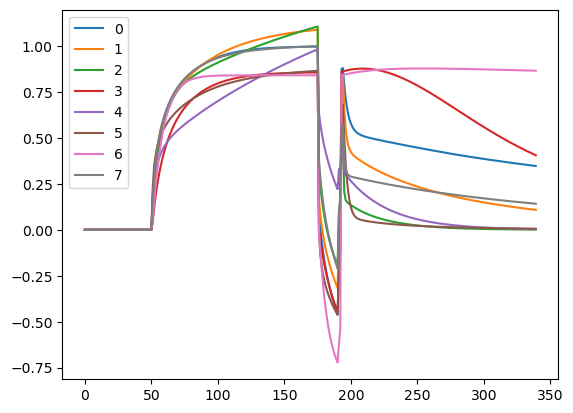

In [ ]:
# plt.plot(ooo['spontaneous'][:,8:] , label='learning')
plt.plot(ooo['evoked'][:,8:])
plt.legend(np.arange(ooo['evoked'].shape[1]))

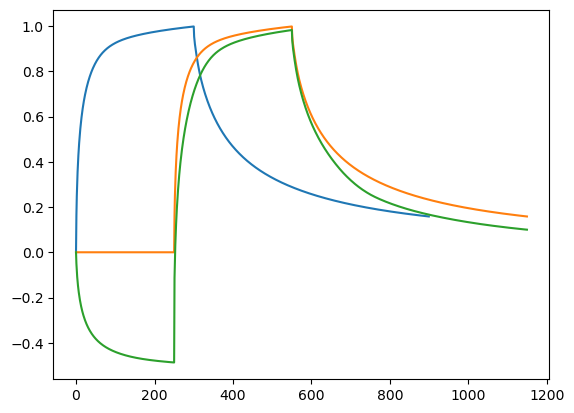

In [ ]:
plt.plot(pooling_fun(ooo['visw1p1'], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['visw1p2'], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['visw1p3'], axis=1) , label='learning')

In [ ]:
# # with open('/homes/ar2342/one_more_dir/contextual_frogs/aux_part2/dataMar18_Inj0.pkl', 'wb') as f:
# with open('/homes/ar2342/one_more_dir/contextual_frogs/aux_part2/dataMar18.pkl', 'wb') as f:
#     pickle.dump(ooo, f)

(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,

/tmp/ipykernel_115476/3457295834.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


(-1.0, 1.2)

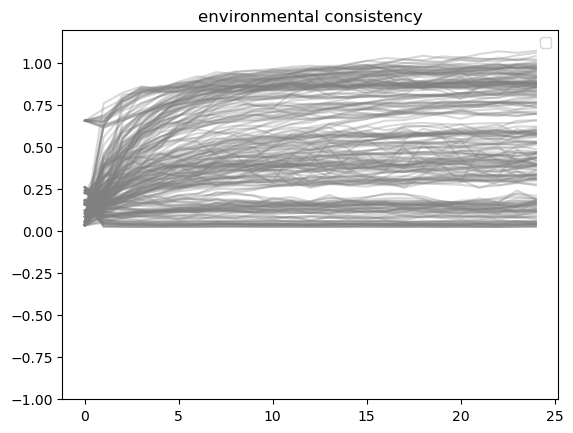

In [ ]:
for k in deltas_by_super_scenario:
    # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
    #present with error bars
    data = np.array(deltas_by_super_scenario[k])
    for datum in data:
        plt.plot(datum, color='gray', alpha=0.3)
        print(datum.shape)
    # mean = np.median(data,axis=0)
    # std = np.std(data,axis=0)
    # plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
    # plt.plot(np.arange(len(mean)),mean,label=k)

plt.legend()
plt.title('environmental consistency')
plt.ylim(-1,1.2)

(-0.1, 1.1)

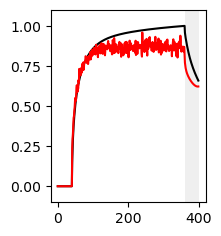

In [ ]:
plt.figure(figsize=(2,2.5))
kk = 15/14
plt.plot(kk*ooo['albert_block_0'].mean(axis=1), label='noiseless albert block', color='black')

# noisy_trials = [ooo[f'albert_block_{ii}'].mean(axis=1) for ii in range(1,101)]
noisy_trials = [ooo[f'albert_block_{ii}'].mean(axis=1) for ii in range(1,100)]
plt.plot(kk*np.mean(noisy_trials, axis=0), label='noisy albert blocks mean', color='red')
plt.axvspan(360, 400, facecolor='gray',  alpha=0.12, zorder=0)
plt.ylim(-0.1,1.1)


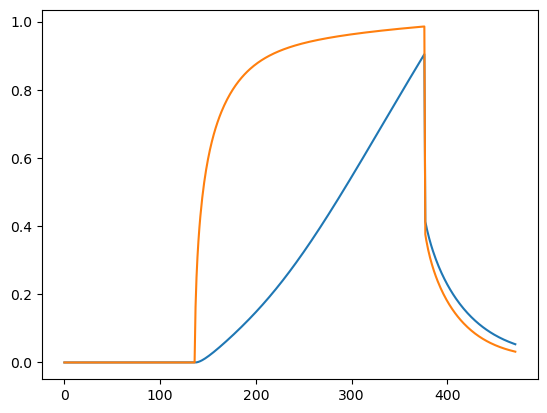

In [ ]:
plt.plot(pooling_fun(ooo['frogs'], axis=1))
plt.plot(pooling_fun(ooo['anti_frogs'], axis=1))

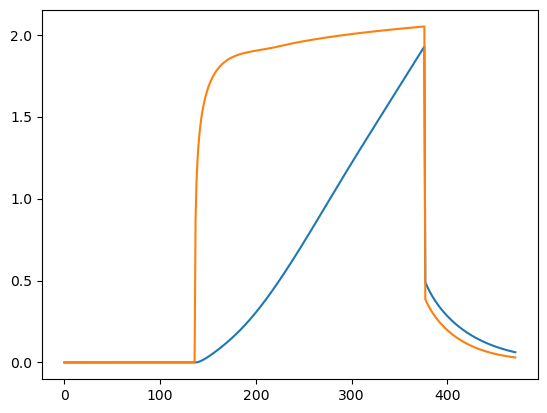

In [ ]:
plt.plot(pooling_fun(ooo['frogs_aug'], axis=1))
plt.plot(pooling_fun(ooo['anti_frogs_aug'], axis=1))

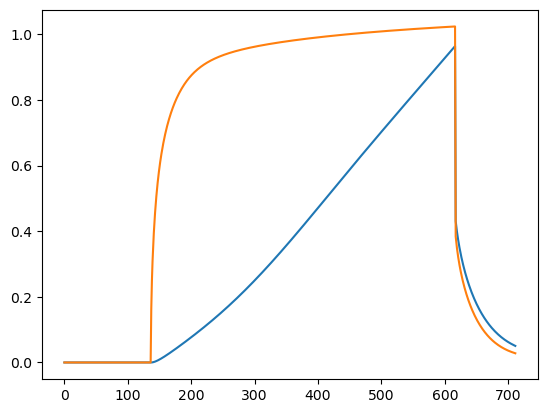

In [ ]:
plt.plot(pooling_fun(ooo['frogs_long'], axis=1))
plt.plot(pooling_fun(ooo['anti_frogs_long'], axis=1))

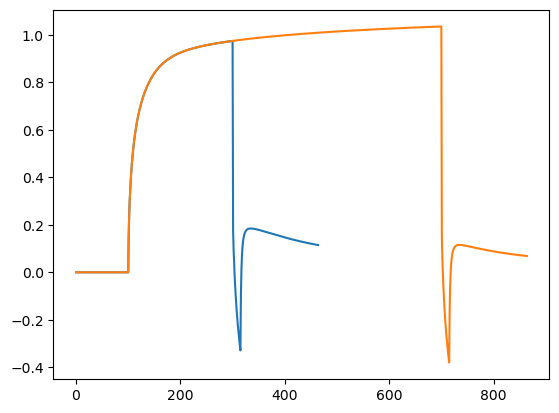

In [ ]:
plt.plot(pooling_fun(ooo['overlearning_baseline'], axis=1))
plt.plot(pooling_fun(ooo['overlearning'], axis=1))

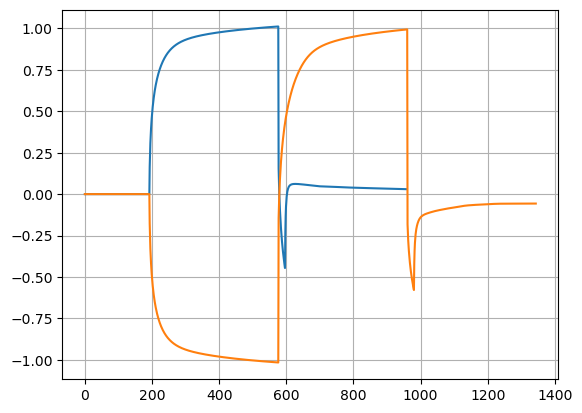

In [ ]:
plt.plot(pooling_fun(ooo['pretrained_sr_baseline'], axis=1))
plt.plot(pooling_fun(ooo['pretrained_sr'], axis=1))
plt.grid()

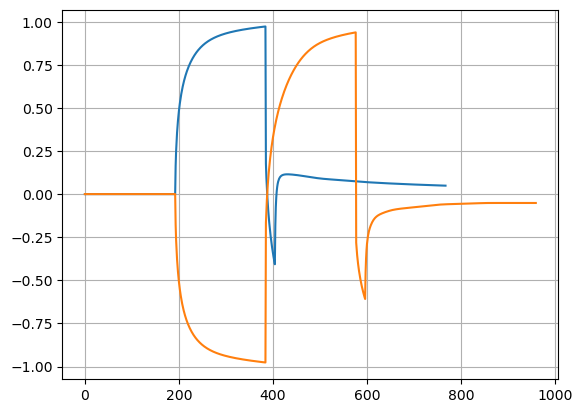

In [ ]:
plt.plot(pooling_fun(ooo['pretrained_sr_baseline0p5'], axis=1))
plt.plot(pooling_fun(ooo['pretrained_sr0p5'], axis=1))
plt.grid()

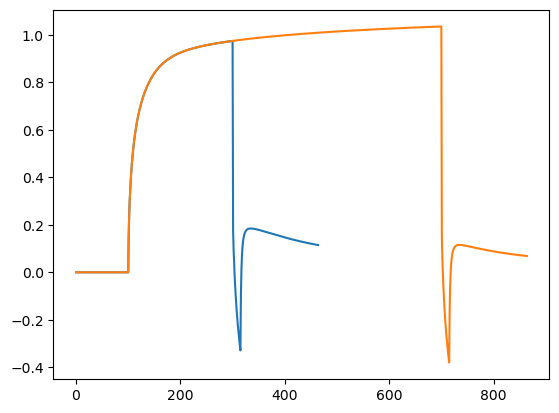

In [ ]:
plt.plot(pooling_fun(ooo['overlearning_baseline'],axis=1))
plt.plot(pooling_fun(ooo['overlearning'],axis=1))

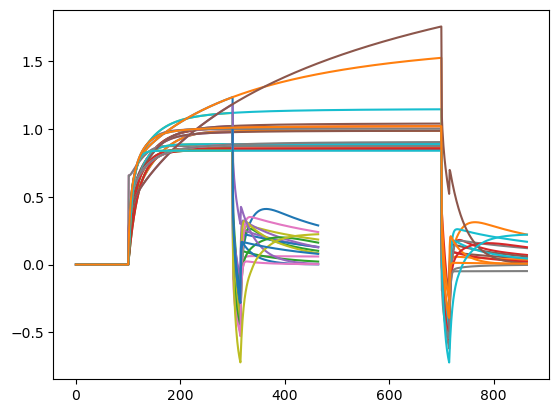

In [ ]:
for ii in range(16):
    plt.plot(ooo['overlearning_baseline'][:,ii])
    plt.plot(ooo['overlearning'][:,ii])

In [ ]:
ooo['overlearning_baseline'].shape

(465, 16)

In [ ]:
#histogram of best seed output scales
best_output_scales = model_state_dict['output_scale'].cpu().numpy().reshape([subjs, seeds])[np.arange(subjs), best_seed_idx]   

In [ ]:
torch.nn.Sigmoid()(best_model_state_dict['direct_injection_scale']).numpy()

KeyError: 'direct_injection_scale'

In [ ]:
best_params = {}
for key in model_state_dict.keys():
    if not key.startswith('_'):  # skip batchnorm running stats
        best_params[key] = model_state_dict[key].cpu().numpy().reshape([subjs, seeds])[np.arange(subjs), best_seed_idx]

In [ ]:
best_params

{'log_learning_rate': array([ -8.562728 ,  -7.7830815,  -8.478531 ,  -8.097224 ,  -9.591697 ,
         -7.1749253, -10.173265 ,  -8.471633 ,  -8.304126 ,  -8.277004 ,
         -9.609505 ,  -8.413945 ,  -9.930866 ,  -6.8864436,  -8.722817 ,
         -9.258123 ], dtype=float32),
 'log_learning_rate_decay': array([4.351906  , 4.285129  , 5.174778  , 4.468098  , 0.06935477,
        5.7340117 , 0.04526445, 5.3121967 , 3.8741775 , 4.597554  ,
        4.784379  , 3.5932176 , 6.7566833 , 4.5552764 , 0.24274428,
        4.29703   ], dtype=float32),
 'sigma_b': array([ 0.2371217 ,  0.21785344,  1.4723974 ,  0.21779025,  0.9387451 ,
         1.0732253 ,  1.1754079 ,  1.4980153 ,  0.78882116, -0.8180631 ,
        -0.97803867,  0.07993639, -1.6896608 ,  0.26076373,  0.7122    ,
        -1.4916391 ], dtype=float32),
 'output_scale': array([1.0032345 , 0.9692079 , 0.97935236, 0.9811695 , 0.9021433 ,
        0.8094852 , 0.99473876, 1.0429312 , 0.98183197, 1.1387095 ,
        2.126635  , 0.88575125, 3.

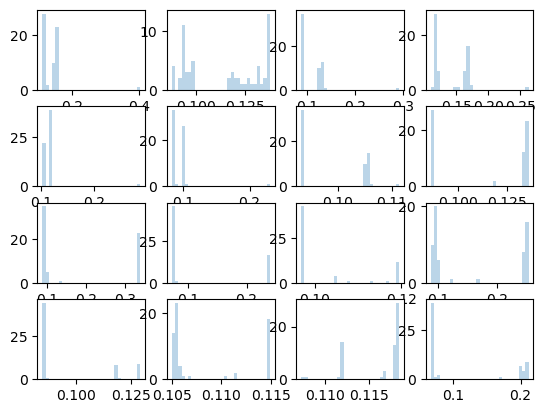

In [ ]:
plt.subplot(4,4,1)
for ii in range(subjs):
    plt.subplot(4,4,1+ii)
    plt.hist(rmse[ii,:], bins=30, alpha=0.3)

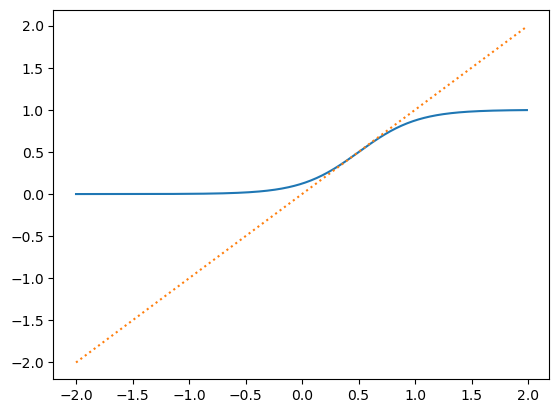

In [ ]:
sss = 0.4
nn = 1000
bbb = sss*np.random.normal(size=nn)
bbext = 0.2
xx = np.arange(-2,2,0.01)
yy = torch.nn.Sigmoid()(torch.tensor(4*xx.reshape(-1,1)-2+bbb.reshape(1,-1))).numpy().mean(axis=1)
plt.plot(xx, yy)
plt.plot(xx,xx,':')

In [ ]:
yy

array([4.84475275e-05, 5.04245929e-05, 5.24823343e-05, 5.46240432e-05,
       5.68531457e-05, 5.91732073e-05, 6.15879391e-05, 6.41012036e-05,
       6.67170209e-05, 6.94395748e-05, 7.22732200e-05, 7.52224886e-05,
       7.82920978e-05, 8.14869568e-05, 8.48121753e-05, 8.82730714e-05,
       9.18751798e-05, 9.56242610e-05, 9.95263105e-05, 1.03587568e-04,
       1.07814528e-04, 1.12213950e-04, 1.16792867e-04, 1.21558602e-04,
       1.26518775e-04, 1.31681315e-04, 1.37054477e-04, 1.42646851e-04,
       1.48467376e-04, 1.54525359e-04, 1.60830481e-04, 1.67392823e-04,
       1.74222873e-04, 1.81331547e-04, 1.88730208e-04, 1.96430678e-04,
       2.04445265e-04, 2.12786775e-04, 2.21468536e-04, 2.30504422e-04,
       2.39908867e-04, 2.49696898e-04, 2.59884149e-04, 2.70486894e-04,
       2.81522068e-04, 2.93007296e-04, 3.04960920e-04, 3.17402028e-04,
       3.30350487e-04, 3.43826968e-04, 3.57852987e-04, 3.72450934e-04,
       3.87644110e-04, 4.03456761e-04, 4.19914123e-04, 4.37042455e-04,
      

In [ ]:
best_model_state_dict['direct_injection_scale']

tensor([ 1.1913, -0.8288,  3.1312, -1.3732,  3.7969,  4.2563, -2.9289,  2.6430,
         1.7514,  4.3071,  2.3715,  3.9876, -2.5030, -0.1430,  1.4200,  2.5428])

In [ ]:
best_model_state_dict['u_feedback_scale']

KeyError: 'u_feedback_scale'

In [ ]:
best_model_state_dict['log_learning_rate']

tensor([[ -8.5036],
        [ -8.1889],
        [ -9.0752],
        [ -7.6101],
        [ -8.4537],
        [ -8.3702],
        [-10.1891],
        [ -6.9374],
        [ -7.6393],
        [ -9.2913],
        [ -7.2290],
        [ -8.2181],
        [-11.7016],
        [ -8.1480],
        [ -7.2848],
        [ -7.4659]])

In [ ]:
best_model_state_dict['log_learning_rate']

tensor([[ -8.5036],
        [ -8.1889],
        [ -9.0752],
        [ -7.6101],
        [ -8.4537],
        [ -8.3702],
        [-10.1891],
        [ -6.9374],
        [ -7.6393],
        [ -9.2913],
        [ -7.2290],
        [ -8.2181],
        [-11.7016],
        [ -8.1480],
        [ -7.2848],
        [ -7.4659]])

In [ ]:
np.exp(best_model_state_dict['log_learning_rate'])*128


tensor([[0.0260],
        [0.0355],
        [0.0147],
        [0.0634],
        [0.0273],
        [0.0297],
        [0.0048],
        [0.1243],
        [0.0616],
        [0.0118],
        [0.0928],
        [0.0345],
        [0.0011],
        [0.0370],
        [0.0878],
        [0.0733]])

In [ ]:
model.debug_lr0.sum(axis=1)

AttributeError: 'BatchedElboGenerativeModelTopMulti' object has no attribute 'debug_lr0'

In [ ]:
for key in best_model_state_dict:
    if not key.startswith('_'):
        print(key, best_model_state_dict[key].reshape(-1))

log_learning_rate tensor([ -8.3617,  -8.1247,  -8.4967,  -5.8379,  -9.4100,  -8.0888, -10.4307,
         -8.3321,  -8.2741,  -8.3314,  -9.7929,  -8.5760, -10.7210,  -7.0298,
         -8.3741,  -9.0634])
log_learning_rate_decay tensor([ 4.2657e+00,  4.2032e+00,  4.9990e+00,  6.1764e+00,  1.4173e+00,
         4.4232e+00,  4.2013e-03,  5.1707e+00,  3.8396e+00,  4.5598e+00,
         4.9993e+00,  3.0870e+00,  6.7557e+00,  4.5118e+00, -1.4903e+00,
         4.4029e+00])
sigma_b tensor([ 0.2012,  0.2980,  1.3175,  0.1976,  0.7285,  0.8187,  1.3013,  1.2038,
         0.5822, -0.7598, -1.0309,  0.1304,  1.8977,  0.2822,  0.2303, -1.3531])
output_scale tensor([0.9901, 1.0367, 1.0008, 0.8757, 0.9077, 0.8662, 1.0177, 1.0595, 1.0085,
        1.1819, 2.4706, 0.8599, 3.7581, 0.9288, 0.8408, 1.0420])
sp_weight_decay tensor([ -8.1878,  -6.1261,  -5.6568,  -9.2078,  -6.7253,  -6.2809,  -4.7845,
         -5.3328,  -7.0769,  -5.1222,  -3.4218,  -8.8017,  -3.4969,  -4.4678,
        -11.6433,  -5.6400])
sigm

In [ ]:
for key in best_model_state_dict:
    if not key.startswith('_'):
        print(key, best_model_state_dict[key].reshape(-1))

log_learning_rate tensor([ -8.2542,  -8.1918,  -8.1082,  -7.4592,  -9.4457,  -8.0151, -10.3804,
         -8.4306,  -8.3648,  -8.2055,  -9.6485,  -8.4772, -10.6201,  -6.9055,
         -8.1705,  -8.9159])
log_learning_rate_decay tensor([ 4.2433,  4.1664,  5.1265,  5.5417,  0.5003,  4.4531, -1.1994,  5.1191,
         3.6296,  4.5287,  4.9760,  3.1114,  6.7664,  4.4922, -0.8342,  4.3795])
sigma_b tensor([ 0.1885,  0.2882,  1.3648,  1.2518,  0.8294,  0.9271,  1.4334,  1.3876,
         0.6484, -0.7762, -1.0546,  0.1361,  2.0578,  0.3247,  0.1321, -1.3672])
output_scale tensor([0.9850, 1.0664, 0.9877, 0.9929, 0.9167, 0.8713, 1.0148, 1.0658, 1.0044,
        1.1878, 2.4703, 0.8596, 3.7779, 0.9304, 0.8153, 1.0452])
sp_weight_decay tensor([ -8.2613,  -6.1613,  -5.6898,  -5.6346,  -6.6327,  -6.1947,  -4.7597,
         -5.2916,  -7.0655,  -5.1402,  -3.4366,  -8.9174,  -3.4983,  -4.3725,
        -11.9049,  -5.6532])
sigma_x tensor([0.1005, 0.1088, 0.0553, 0.0325, 0.0921, 0.0340, 0.0220, 0.0712, 0.03

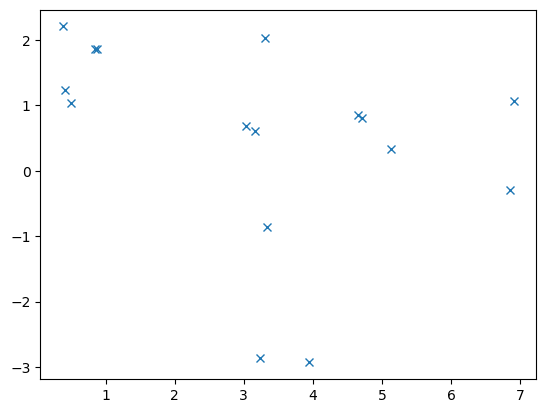

In [ ]:
plt.plot( best_model_state_dict['scsp_w_in_lr_'].reshape(-1), best_model_state_dict['scsp_w_in_decay_'].reshape(-1),'x')

In [ ]:
best_model_state_dict['sp_weight_decay']

tensor([[-7.0253, -2.2173],
        [-6.4083, -0.3292],
        [-5.6751,  1.4103],
        [ 0.0729, -6.9838],
        [-1.7333, -5.9443],
        [-5.5832,  0.6502],
        [-4.6110, -1.4350],
        [-5.7155,  0.9017],
        [-0.5803, -6.9070],
        [-5.2635,  0.4266],
        [-4.1996,  1.3261],
        [-3.1830, -6.7770],
        [-4.1871,  0.8330],
        [-4.4521, -0.6007],
        [-8.4699, -2.9765],
        [ 1.5468, -5.6760]])

In [ ]:
best_model_state_dict['output_scale']

tensor([1.0175, 1.0832, 0.8990, 0.9687, 0.9536, 0.9727, 0.8093, 1.1681, 0.9845,
        1.2220, 2.3499, 0.7986, 3.9132, 0.9858, 0.7938, 1.0301])

In [ ]:
best_model_state_dict['weight_decay_exp']

tensor([[2.0808],
        [0.9450],
        [1.1880],
        [2.1035],
        [1.1311],
        [1.1508],
        [0.6067],
        [1.1646],
        [2.0996],
        [2.0544],
        [0.5691],
        [1.4121],
        [0.6120],
        [0.6636],
        [1.6556],
        [1.1629]])

In [ ]:
best_model_state_dict['weight_learning_exp']

tensor([[0.5334],
        [0.5426],
        [0.6072],
        [0.5542],
        [0.7000],
        [0.6433],
        [1.1701],
        [0.5534],
        [0.5206],
        [0.5440],
        [1.1434],
        [0.6275],
        [0.6173],
        [1.2276],
        [1.6392],
        [0.6333]])

In [ ]:
model.args

namespace(apply_lr_decay=True,
          assume_opt_output_noise=True,
          bs=24,
          channel_trial_extra_error=0.0,
          direct_inj_limiter=1.0,
          disable_lpfs=True,
          enable_direct_injection=True,
          enable_elpf=False,
          enable_output_scale_tuning=True,
          enable_q_scale_tuning=True,
          enable_qlpf=False,
          enable_u_feedback_scale_tuning=False,
          enable_ylpf=False,
          injection_opt=3,
          lr_min_mult=0.1,
          model='default',
          model_tie_lr_weight_decay=False,
          multirate_m=1,
          n=256,
          nl_activation='relu',
          noise_injection_node='a',
          optimizer_alg='RMSprop',
          skip_gain=0.0,
          weight_decay_mode='softplus',
          zzz_legacy_init=False)

In [ ]:
ooo.keys()

dict_keys(['savings', 'AB0', 'AB1', 'AB2', 'AB3', 'AB4', 'AB5', 'spontaneous', 'evoked', 'visw1p2', 'visw1p1', 'visw1p3', 'albert_block_0', 'albert_block_1', 'albert_block_2', 'albert_block_3', 'albert_block_4', 'albert_block_5', 'albert_block_6', 'albert_block_7', 'albert_block_8', 'albert_block_9', 'albert_block_10', 'albert_block_11', 'albert_block_12', 'albert_block_13', 'albert_block_14', 'albert_block_15', 'albert_block_16', 'albert_block_17', 'albert_block_18', 'albert_block_19', 'albert_block_20', 'albert_block_21', 'albert_block_22', 'albert_block_23', 'albert_block_24', 'albert_block_25', 'albert_block_26', 'albert_block_27', 'albert_block_28', 'albert_block_29', 'albert_block_30', 'albert_block_31', 'albert_block_32', 'albert_block_33', 'albert_block_34', 'albert_block_35', 'albert_block_36', 'albert_block_37', 'albert_block_38', 'albert_block_39', 'albert_block_40', 'albert_block_41', 'albert_block_42', 'albert_block_43', 'albert_block_44', 'albert_block_45', 'albert_block_

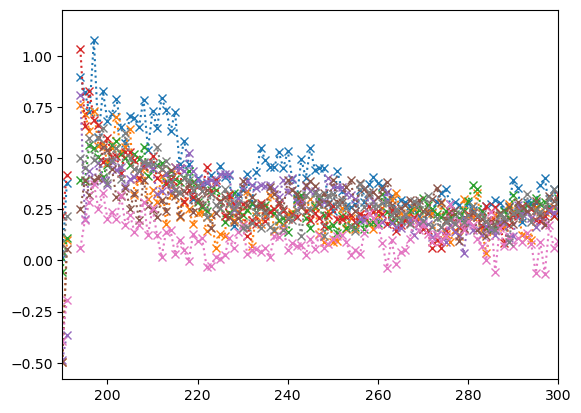

In [ ]:
for k in range(8):
    dd = a_exp[:,seeds*k]
    dd = dd*np.sign(np.nansum(dd))
    plt.plot(dd,':x')
    plt.xlim([190,300])

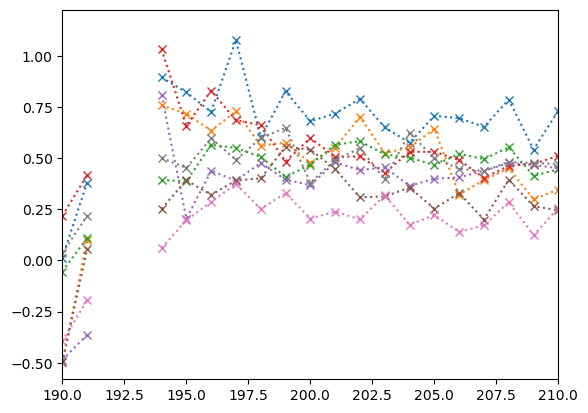

In [ ]:
for k in range(8):
    dd = a_exp[:,seeds*k]
    dd = dd*np.sign(np.nansum(dd))
    plt.plot(dd,':x')
    plt.xlim([190,210])

In [ ]:
p = np.sign(np.nansum(a_exp[:175,::seeds],axis=0))
dd = a_exp[:,::seeds]

Text(0.5, 1.0, 'ER: just before and just after the P+')

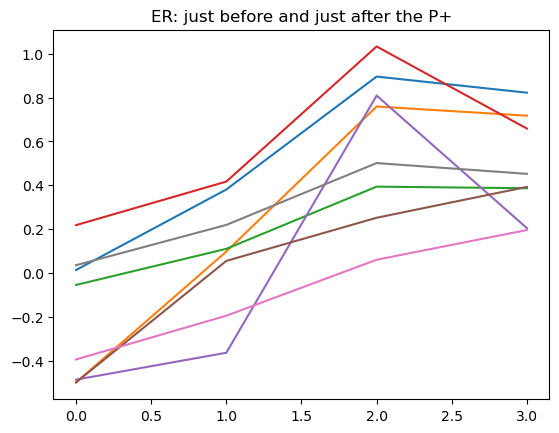

In [ ]:
plt.plot(dd[[190,191,194,195],:8]*p[:8])
plt.title('ER: just before and just after the P+')

(array([1., 0., 0., 0., 3., 3., 2., 3., 3., 1.]),
 array([-1.10669494, -0.97418321, -0.84167148, -0.70915975, -0.57664801,
        -0.44413628, -0.31162455, -0.17911282, -0.04660109,  0.08591064,
         0.21842237]),
 <BarContainer object of 10 artists>)

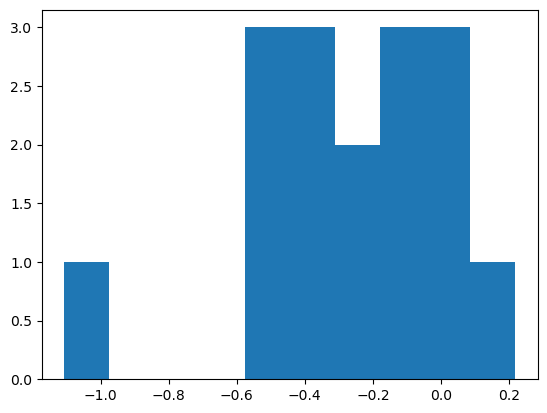

In [ ]:
plt.hist(dd[190,:]*p)

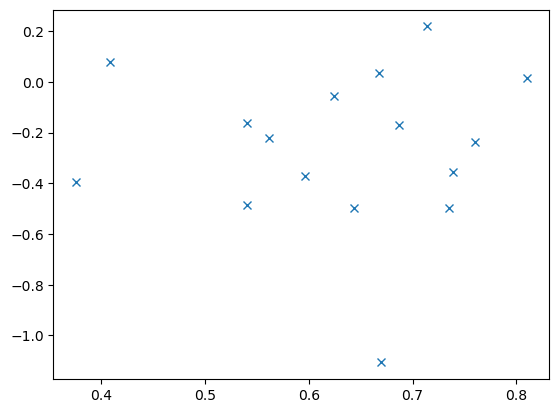

In [ ]:
plt.plot(np.nanmean(dd[50:80,:]*p, axis=0), dd[190,:]*p, 'x')

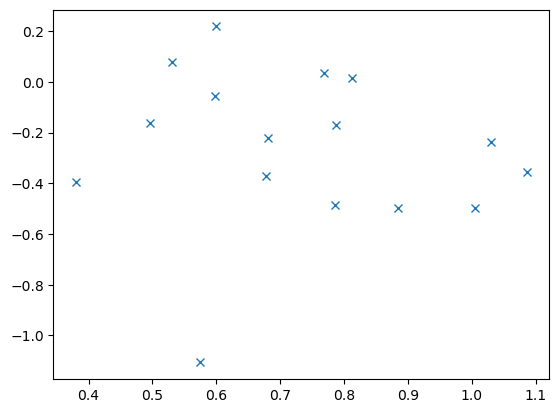

In [ ]:
plt.plot(np.nanmean(dd[60:70,:]*p, axis=0), dd[190,:]*p, 'x')

In [ ]:
from scipy.stats import spearmanr
spearmanr(np.nanmean(dd[60:70,:]*p, axis=0), dd[190,:]*p)

SignificanceResult(statistic=-0.22941176470588234, pvalue=0.39272049088161975)

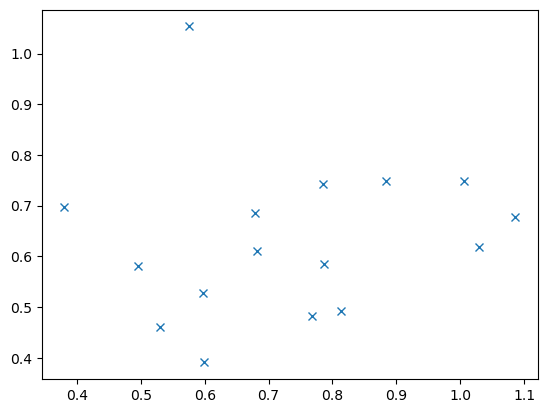

In [ ]:
plt.plot(np.nanmean(dd[60:70,:]*p, axis=0), (1-dd[190,:]*p)/2, 'x')

In [ ]:
template = 'multirate'#'state-space'
mode = 'ERSR'
n_subjects = 1
n_seeds = 1
priority_intervals = None
priority_factor = None
if template == 'lr_reduct':
        args = SimpleNamespace(
        model='default',
        enable_q_scale_tuning= mode == 'MU',
        assume_opt_output_noise=True,
        enable_qlpf=False,
        enable_ylpf=False,
        enable_elpf=False,
        multirate_m=1,          # 
        apply_lr_decay=True, #False,
        noise_injection_node='a',
        model_tie_lr_weight_decay=False,
        bs=n_subjects * n_seeds,                      # IMPORTANT: one batch entry per subject
        zzz_legacy_init=False,
        enable_output_scale_tuning= True, #False,# mode == 'MU',
        enable_u_feedback_scale_tuning=False, #True,
        enable_direct_injection= True , #mode == 'MU',
        injection_opt=3,            # 
        skip_gain=0.0,
        channel_trial_extra_error=0.0,
        lr_min_mult = 1e-1,
        weight_decay_mode='softplus', #'sigmoid', #
        # weight_decay_mode='sigmoid',
        nl_activation='relu',
        n=128 if mode == 'ERSR' else 256,
        disable_lpfs=True,
        optimizer_alg='RMSprop',
        n_seeds=n_seeds,
        # direct_inj_limiter=0.45,
    )
elif template == 'multirate':
    args = SimpleNamespace(
        model='default',
        enable_q_scale_tuning= mode == 'MU',
        assume_opt_output_noise=True,
        enable_qlpf=False,
        enable_ylpf=False,
        enable_elpf=False,
        multirate_m=1,          # 
        apply_lr_decay=False, #False,
        noise_injection_node='a',
        model_tie_lr_weight_decay=False,
        bs=n_subjects * n_seeds,                      # IMPORTANT: one batch entry per subject
        zzz_legacy_init=False,
        enable_output_scale_tuning= False, #False,# mode == 'MU',
        enable_u_feedback_scale_tuning=False, #True,
        enable_direct_injection= True , #mode == 'MU',
        injection_opt=3,            # 
        skip_gain=0.0,
        channel_trial_extra_error=0.0,
        lr_min_mult = 1e-1,
        weight_decay_mode='softplus', #'sigmoid', #
        # weight_decay_mode='clipped_sigmoid',
        weight_decay_max=1.0,
        nl_activation= 'rescaled_sigmoid',#'rescaled_sigmoid',#'relu', #['relu', 'const'], # 'rescaled_sigmoid', #'relu', #
        n=128 if mode == 'ERSR' else 256,
        disable_lpfs=True,
        optimizer_alg= 'RMSprop', # 'RMSprop',
        n_seeds=n_seeds,
        priority_intervals=priority_intervals,
        priority_factor=priority_factor,
        lr_bound = None, #1./512.,
        bound_weight_decay = True,
        enable_weight_learning_exp = True,
        enable_weight_decay_exp = True,
        enable_bias_update = False,
        develop_b_tgt = -2.0,
        enable_w_in_plasticity = True,

        # direct_inj_limiter=0.45,
    )
elif template == 'state-space':
    args = SimpleNamespace(
        model='default',
        enable_q_scale_tuning= mode == 'MU',
        assume_opt_output_noise=True,
        enable_qlpf=False,
        enable_ylpf=False,
        enable_elpf=False,
        multirate_m=1,          # 
        apply_lr_decay=False, #False,
        noise_injection_node='a',
        model_tie_lr_weight_decay=False,
        bs=n_subjects * n_seeds,                      # IMPORTANT: one batch entry per subject
        zzz_legacy_init=False,
        enable_output_scale_tuning= False, #False,# mode == 'MU',
        enable_u_feedback_scale_tuning=False, #True,
        enable_direct_injection= False , #mode == 'MU',
        injection_opt=3,            # you’re using opt=2 in the model code
        skip_gain=0.0,
        channel_trial_extra_error=0.0,
        lr_min_mult = 1e-1,
        weight_decay_mode='softplus', #'sigmoid', #
        # weight_decay_mode='clipped_sigmoid',
        weight_decay_max=1.0,
        nl_activation='const', #['relu', 'const'], # 'rescaled_sigmoid', #'relu', #
        n=1 if mode == 'ERSR' else 256,
        disable_lpfs=True,
        optimizer_alg= 'RMSprop', # 'RMSprop',
        n_seeds=n_seeds,
        priority_intervals=priority_intervals,
        priority_factor=priority_factor,
        enable_sigma_b_tuning = False,
        lr_bound = None, #0.99,
        bound_weight_decay = True,
        enable_weight_decay_exp = True,
        enable_weight_learning_exp = True,
        enable_bias_update = True
        # direct_inj_limiter=0.45,
    )

In [ ]:
model = BatchedElboGenerativeModelTopMulti(device=device, args=args).to(device)
model.get_biases_and_w_in(args.n, device=device)


(tensor([[ 0.0504, -0.6542,  0.1057,  0.8525, -0.0510,  0.0358,  0.2735, -0.2431,
           0.3110, -0.2728,  0.4888,  0.1611,  0.3387, -0.2516, -0.1031,  0.0723,
          -0.1146, -0.0565,  0.5255, -0.2016,  0.4458, -0.6245,  0.2140,  0.3246,
          -0.8554, -0.1893,  0.5485,  0.6955,  0.0921,  0.0433,  0.3781, -0.4911,
           0.2981,  0.0761, -0.2190, -0.3054, -0.2167, -0.0393,  0.1958,  0.0134,
          -0.0436, -0.0912,  0.2099,  0.0311, -0.2707, -0.7426,  0.1453, -0.0114,
          -0.4138, -0.4529,  0.4656, -0.6175, -0.4555, -0.5340, -0.3283,  0.1538,
          -0.1774, -0.2352,  0.1361,  0.0985,  0.5355, -0.1737,  0.0514, -0.6489,
           0.1751,  0.2077,  0.1641, -0.2215, -0.6385, -0.4455,  0.3846,  0.7606,
           0.1109,  0.0208,  0.2984,  0.1029,  0.1694,  0.3426, -0.0880,  0.3739,
           0.3389,  0.0367, -0.0415, -0.2672, -0.1364,  0.0655,  0.3116,  0.0716,
          -0.1372,  0.0047,  0.2006, -0.3774, -0.3000, -0.5203,  0.9797, -0.0913,
          -0.504

In [ ]:
model_state_dict = model.state_dict()
k_params = compute_k_params(model_state_dict)

param: log_learning_rate, size: 1
param: sigma_b, size: 1
param: sp_weight_decay, size: 1
param: weight_decay_exp, size: 1
param: weight_learning_exp, size: 1
param: w_in_lr, size: 1
param: w_in_decay, size: 1
param: direct_injection_scale, size: 1


In [ ]:
from model_utils import force_model_params




In [ ]:
from optimise_clnn import load_subject_data

all_ys = []
all_a_exp = []
all_qs = []
lengths = []

mode =  'ERSR' #'ERSR' #'MU' 
paradigm_ = {k: 'evoked' if k <= 8 else 'spontaneous' for k in range(1, 17)}

for k in range(1, n_subjects + 1):
    if mode == 'ERSR':
        csv_path = f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_{paradigm_[k]}_recovery_participant{(k-1)%8+1}.csv'
    else:
        csv_path = f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_memory_updating_participant{k}.csv'
    experimental_data = load_subject_data(csv_path)

    a_exp = np.asarray(experimental_data[0], dtype=np.float32)  # target (your a_exp)
    ys    = np.asarray(experimental_data[1], dtype=np.float32)  # input ys (your ys)
    if mode == 'MU':
        qs = np.asarray(experimental_data[2], dtype=np.float32)  # input qs (your qs)

    for _ in range(n_seeds):
        all_a_exp.append(a_exp)
        all_ys.append(ys)
        if mode == 'MU':
            all_qs.append(qs)
        lengths.append(len(a_exp))

In [ ]:
outputs = []
# pp_list = [0.25, 0.5,1,2,3]
pp_list = [0.0,3e-3,1e-2,3e-2,1e-1]
for pp in pp_list:
    forced_params = {
                    #'log_learning_rate_decay': -20., 
                    # 'sigma_x': 1e-7, 
                    'log_learning_rate': -5.50,
                    'sp_weight_decay': -6.5,
                    # 'output_scale': 1.0,
                    # 'u_feedback_scale': 1.0,
                    'sigma_b': 0.5,
                    #'q_scale': 0.9,
                    #  'tauelpf_m1': -1000.0,
                    #  'tauqlpf_m1': -1000.0,
                     'direct_injection_scale': 0.5,
                    'weight_decay_exp': 1.0,
                    'weight_learning_exp': 1.0,
                    'weight_decay_exp': 1.0,
                    'bias_lr':pp,
                    }
    force_model_params(model, forced_params)


    ys = torch.tensor(all_ys[0], device=next(model.parameters()).device)
    #duplicate ys across batch size
    ys = ys.unsqueeze(0).repeat(args.bs, 1)  # [bs, t]
    print(f'ys shape after unsqueeze and repeat: {ys.shape}')
    # noises = torch.randn((args.bs, ys.shape[1]), device=next(model.parameters()).device) * model.sigma_x  # [bs, t]
    noises = torch.zeros((args.bs, ys.shape[1]), device=next(model.parameters()).device)  # [bs, t]
    print(f'noises shape before splitting: {noises.shape}')
    noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
    print(f'noises shape after splitting: {noises[0].shape}, number of noise tensors: {len(noises)}')
    ys = [ys[:, t_idx] for t_idx in range(ys.shape[1])]
    print(f'noises shape: {noises[0].shape}, ys shape: {ys[0].shape}')
    model_setting = args.model
    outputs_ = model.f(args.n,
                        noises,
                        ys,  
                        model_setting,
                        qs=None,
                        )
    outputs.append(np.array([z.cpu().detach().numpy().reshape(-1) for z in outputs_]))
# plt.ylim(-1.2,1.2)

Forcing parameter log_learning_rate to value -5.5
Forcing parameter sigma_b to value 0.5
Forcing parameter sp_weight_decay to value -6.5
Forcing parameter weight_decay_exp to value 1.0
Forcing parameter weight_learning_exp to value 1.0
Forcing parameter direct_injection_scale to value 0.5
ys shape after unsqueeze and repeat: torch.Size([1, 340])
noises shape before splitting: torch.Size([1, 340])
noises shape after splitting: torch.Size([1]), number of noise tensors: 340
noises shape: torch.Size([1]), ys shape: torch.Size([1])


/scratch/ar2342/miconda3/envs/py_frogs/lib/python3.9/site-packages/torch/nn/functional.py:1967: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


RuntimeError: einsum(): the number of subscripts in the equation (2) does not match the number of dimensions (3) for operand 1 and no ellipsis was given

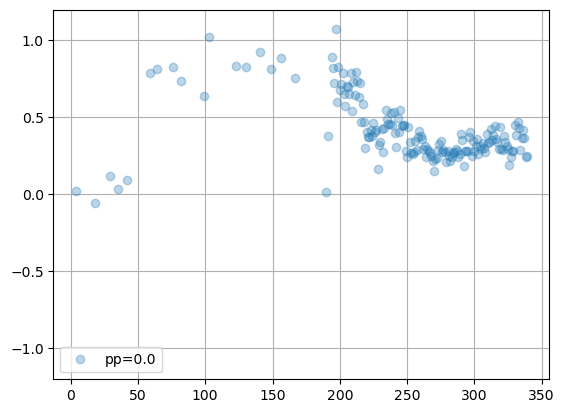

In [ ]:
for oo, out in enumerate(outputs):
    print(out.shape)
    plt.plot(out,'-')
plt.plot(a_exp, 'o',alpha=0.3)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['experimental'], loc='lower left')
# plt.plot(outputs[0],'-',linewidth=3, color='black')
# plt.xlim(188,200)#,53)
plt.grid()

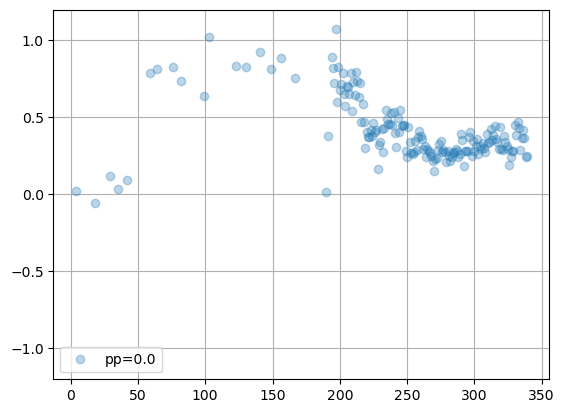

In [ ]:
for oo, out in enumerate(outputs):
    print(out.shape)
    plt.plot(out,'-')
plt.plot(a_exp, 'o',alpha=0.3)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['experimental'], loc='lower left')
# plt.plot(outputs[0],'-',linewidth=3, color='black')
# plt.xlim(188,200)#,53)
plt.grid()

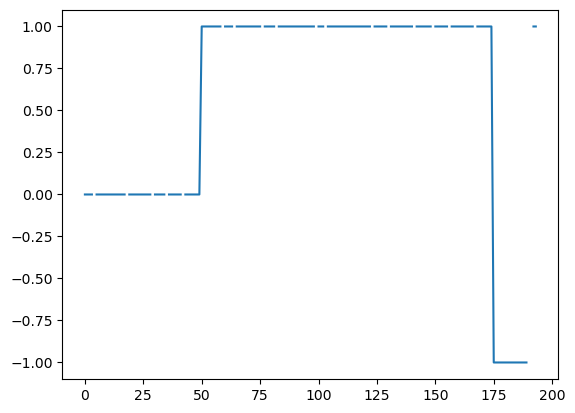

In [ ]:
plt.plot(all_ys[0])

In [ ]:
a_exp


array([        nan,         nan,         nan,         nan,  0.02277484,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan, -0.0534388 ,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,  0.12124509,
               nan,         nan,         nan,         nan,         nan,
        0.03530996,         nan,         nan,         nan,         nan,
               nan,         nan,  0.09142897,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,  0.7877995 ,
               nan,         nan,         nan,         nan,  0.8127609 ,
               nan,         nan,         nan,         nan,      

In [ ]:

def read_rmse_and_bic_from_path(bic_path,seeds):
    model_state_dict = torch.load(os.path.join(bic_path, 'model_state_dict.pt'), map_location='cpu')
    k_params = compute_k_params(model_state_dict)
    print(f'detected k_params: {k_params}')
    a_exp = np.loadtxt(os.path.join(bic_path, 'a_exp.txt'))
    a_pred = np.loadtxt(os.path.join(bic_path, 'a_pred.txt'))

    subjs = a_exp.shape[1] // seeds
    print(f'detected subjs: {subjs}')

    rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
    n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
    assert np.all(n_samples == n_samples[:, [0]])
    n_samples = n_samples[:, 0]

    best_seed_idx = np.nanargmin(rmse, axis=1)
    best_rmse = rmse[np.arange(subjs), best_seed_idx]
    best_bics = [bic_gaussian_from_rmse(this_rmse, n=this_n, k=k_params) for this_rmse, this_n in zip(best_rmse, n_samples)]
    return {"best_rmse": np.array(best_rmse), "best_bics": np.array(best_bics)}

In [ ]:
ms = [1,2]
gs = [1,2]
clln_flags = [False, True]
outs = {}
for
for m in ms:
    for g in gs:
        result_path = f'/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group{g}_{"CLNN" if clnn_flag else ""}m{m}/'
        '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group1_CLNNm2/'
        outs[(g, m)] = read_rmse_and_bic_from_path(result_path, seeds=128)

SyntaxError: invalid syntax (2362913442.py, line 5)

In [ ]:
outs[(1,1)]['best_bics']-outs[(1,2)]['best_bics']

NameError: name 'outs' is not defined

NameError: name 'gs' is not defined

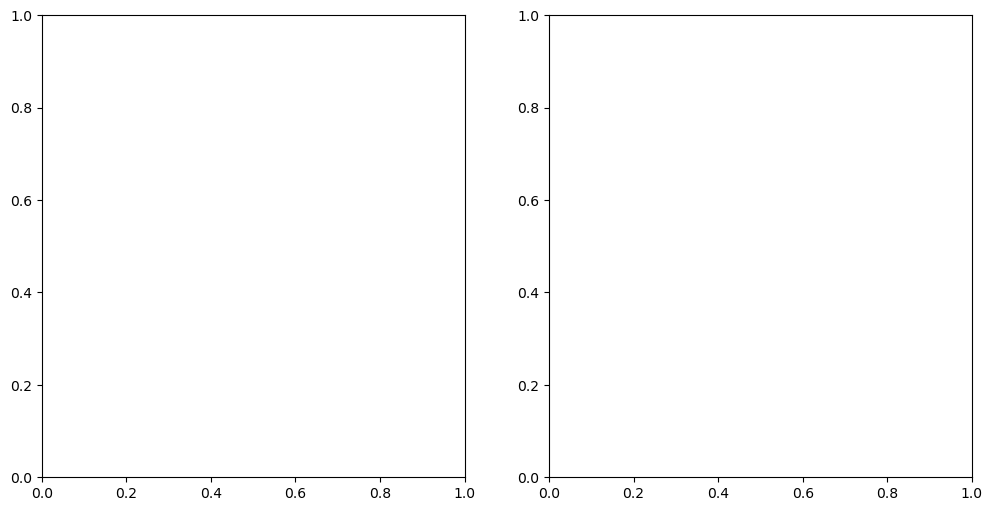

In [ ]:
plt.subplots(1,2, figsize=(12,6))
for i, g in enumerate(gs):
    plt.subplot(1,2,i+1)
    plt.stem(outs[(g,1)]['best_bics']-outs[(g,2)]['best_bics'])
    plt.title(f'group {g}')
    plt.xlabel('participant')
    if i==0:
        plt.ylabel('multirate BIC difference\nm=1 minus m=2\npositive = m=2 better')

In [ ]:
slowing_down_bics = read_rmse_and_bic_from_path('/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_LRmin_basicBwdCapatRMSprop_NEW/', seeds=128)

param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5


In [ ]:
dual_rate_bics = read_rmse_and_bic_from_path('/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group1_m2/', seeds=128)
xconsolidation_bics = read_rmse_and_bic_from_path('/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group1_CLNNm1Xconsolidation/', seeds=128)

param: log_learning_rate, size: 2
param: sp_weight_decay, size: 2
detected k_params: 4
param: log_learning_rate, size: 1
param: sigma_b, size: 1
param: sp_weight_decay, size: 1
param: x_slow_alpha, size: 1
param: x_fast_gain, size: 1
detected k_params: 5


/tmp/ipykernel_1007404/419064470.py:10: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])


<StemContainer object of 3 artists>

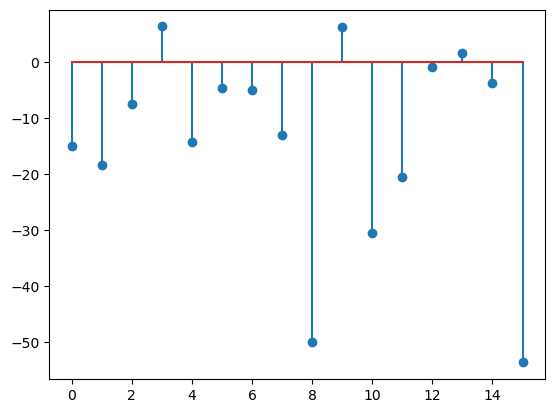

In [ ]:
plt.stem(slowing_down_bics['best_bics'] - dual_rate_bics['best_bics'])

<StemContainer object of 3 artists>

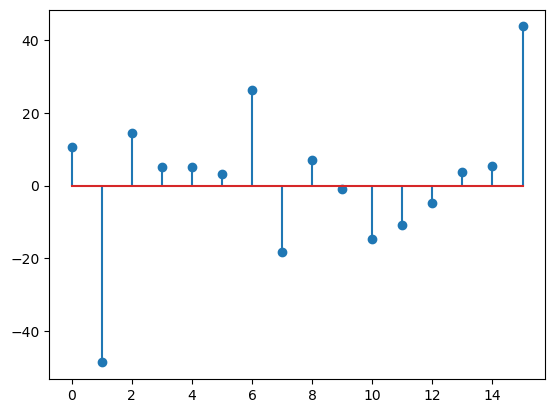

In [ ]:
plt.stem(xconsolidation_bics['best_bics'] - dual_rate_bics['best_bics'])

In [ ]:
dual_rate_bics

{'best_rmse': array([0.1484945 , 0.15463776, 0.11533262, 0.30985589, 0.15546782,
        0.15663422, 0.12667992, 0.15403454, 0.16300271, 0.31236461,
        0.19450053, 0.16488302, 0.2476111 , 0.12852243, 0.19182354,
        0.06255188]),
 'best_bics': array([-119.79350727, -108.1997922 , -192.07359317,   90.57648184,
        -106.66872197, -104.5310155 , -165.23442862, -109.3176259 ,
         -93.13289581,   92.88273176,  -42.60583396,  -89.85264089,
          26.44157192, -161.10462386,  -46.56950988, -367.05527339])}

In [ ]:
run1 = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_rich_scsp_repeat/'
run2 = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_rich_scsp/'

run1 ='/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_NEWveryFudgeDisabled/'
run2 = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_NEWveryFudgeDisabled_try2/'


param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5
param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5


/tmp/ipykernel_1775670/419064470.py:10: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])


<StemContainer object of 3 artists>

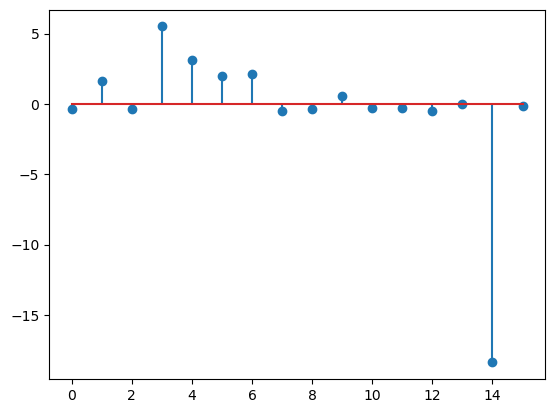

In [ ]:
#compare bics
bic1 = read_rmse_and_bic_from_path(run1, seeds=128//2)['best_bics']
bic2 = read_rmse_and_bic_from_path(run2, seeds=128//2)['best_bics']
plt.stem(bic1 - bic2)

In [ ]:


lerner_dual_rate_bics = read_rmse_and_bic_from_path('/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group1_m2/', seeds=128)
signoff_candidate_bics = read_rmse_and_bic_from_path('/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_g1_part2_LRmin_basicBwdCapatRMSprop_NEWveryFudgeDisabled_LRrecover5em3_noLRmin/', seeds=128//2)

param: log_learning_rate, size: 2
param: sp_weight_decay, size: 2
detected k_params: 4
detected subjs: 16
param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5
detected subjs: 16


<StemContainer object of 3 artists>

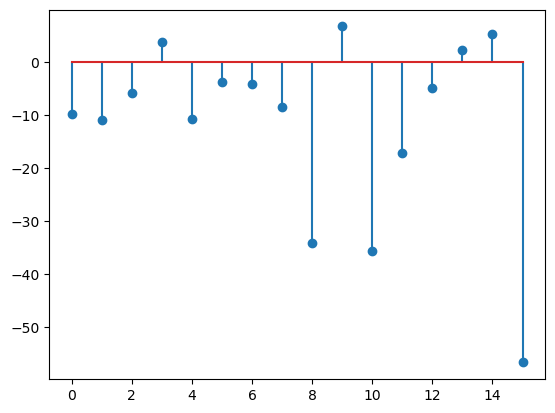

In [ ]:
plt.stem(signoff_candidate_bics['best_bics'] - lerner_dual_rate_bics['best_bics'])

In [ ]:
runs = [f'/homes/ar2342/one_more_dir/contextual_frogs/results_part2/default_with_seeds_{i}' for i in range(1,6)]

In [ ]:
bics = [read_rmse_and_bic_from_path(run, seeds=128//2)['best_bics'] for run in runs]

param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5
detected subjs: 16


/tmp/ipykernel_115476/4101126321.py:11: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])


param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5
detected subjs: 16
param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5
detected subjs: 16
param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5
detected subjs: 16
param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
detected k_params: 5
detected subjs: 16


In [ ]:
bics

[array([-231.03852963, -287.87632614, -311.80370859, -210.03188574,
        -253.39134178, -303.44007142, -287.03499237, -314.73565855,
        -313.75071765, -366.89416332, -280.08939414, -322.80903706,
        -325.12366069, -252.90532959, -280.05718305, -398.98137542]),
 array([-222.69272996, -287.02807116, -311.28431422, -219.6972899 ,
        -255.49171438, -305.37821399, -287.60079299, -314.61806277,
        -314.22105319, -361.20303098, -279.92970932, -322.24421272,
        -325.09746974, -253.2684489 , -277.43494459, -398.87391349]),
 array([-228.49189396, -286.22561553, -311.24499053, -219.96447182,
        -255.96663964, -307.21518426, -287.30242692, -314.94624776,
        -315.63866316, -364.26124303, -280.00126032, -325.4625161 ,
        -325.23783454, -253.07837489, -276.73092667, -398.57284176]),
 array([-229.88706672, -292.6604622 , -309.55680936, -276.80705305,
        -251.20196721, -301.62157171, -285.4392115 , -314.71095325,
        -313.75823684, -369.63326034, -280

Text(0, 0.5, 'BIC difference from mean across runs')

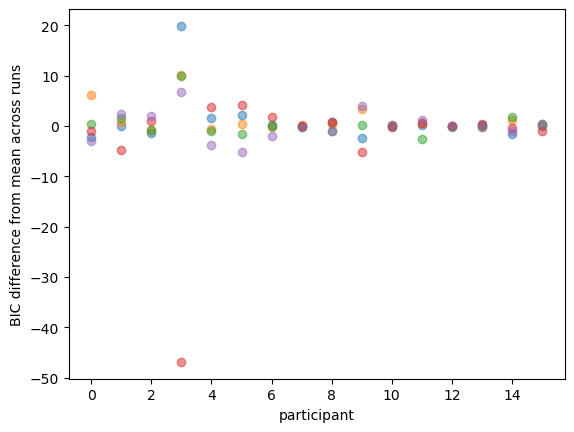

In [ ]:
for bic in bics:
    plt.plot(bic - np.mean(bics, axis=0), 'o', alpha=0.5)
plt.xlabel('participant')
plt.ylabel('BIC difference from mean across runs')